## Model Risk, Ethics, and Governance

This notebook discusses non-technical considerations including
fairness, ethical usage, limitations, and monitoring strategies.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
path = "/content/drive/MyDrive/Credit_Risk_Project/data/behavioral_features.csv"
df = pd.read_csv(path)

df.shape

(30000, 31)

In [ ]:
features = [
    'pay_delay_trend',
    'pay_delay_volatility',
    'recency_weighted_stress',
    'bill_payment_ratio'
]

X = df[features]
y = df['default']

In [ ]:
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X, y)

RandomForestClassifier(max_depth=6, min_samples_leaf=50, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [ ]:
early_warning_features = [
    col for col in df.columns
    if col.startswith('PAY_') and col != 'PAY_0'
] + [
    'LIMIT_BAL',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
    'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3'
]

X_early = df[early_warning_features]
y = df['default']

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_early = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)

rf_early.fit(X_early, y)

RandomForestClassifier(max_depth=6, min_samples_leaf=50, n_estimators=300,
                       n_jobs=-1, random_state=42)

### Fairness and Bias Considerations

Potential sources of bias and their implications are examined.


In [ ]:
import pandas as pd

early_importance = pd.Series(
    rf_early.feature_importances_,
    index=early_warning_features
).sort_values(ascending=False)

early_importance.head(10)

,0
PAY_2,0.287713
PAY_3,0.154746
PAY_4,0.110208
PAY_5,0.094246
PAY_6,0.077107
PAY_AMT1,0.039281
PAY_AMT1,0.036289
LIMIT_BAL,0.030093
PAY_AMT2,0.021794
PAY_AMT2,0.018600


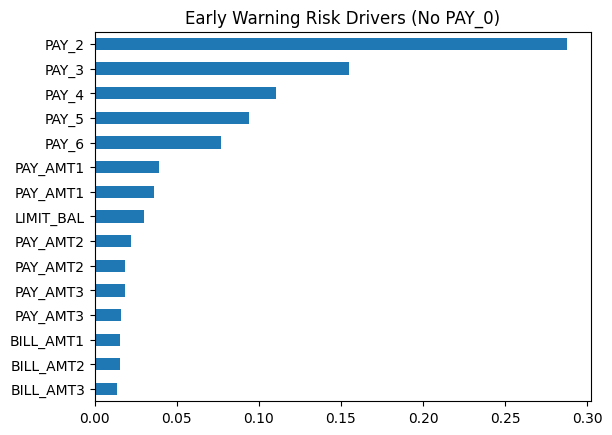

In [ ]:
import matplotlib.pyplot as plt

early_importance.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Early Warning Risk Drivers (No PAY_0)")
plt.show()

In [ ]:
df['risk_score'] = final_model.predict_proba(X)[:, 1]

df[['risk_score']].describe()

,risk_score
count,30000.000000
mean,0.221373
std,0.184617
min,0.096058
25%,0.104359
50%,0.123858
75%,0.259443
max,0.866751


In [ ]:
df[['risk_score', 'default']].describe()

,risk_score,default
count,30000.000000,30000.000000
mean,0.221373,0.221200
std,0.184617,0.415062
min,0.096058,0.000000
25%,0.104359,0.000000
50%,0.123858,0.000000
75%,0.259443,0.000000
max,0.866751,1.000000


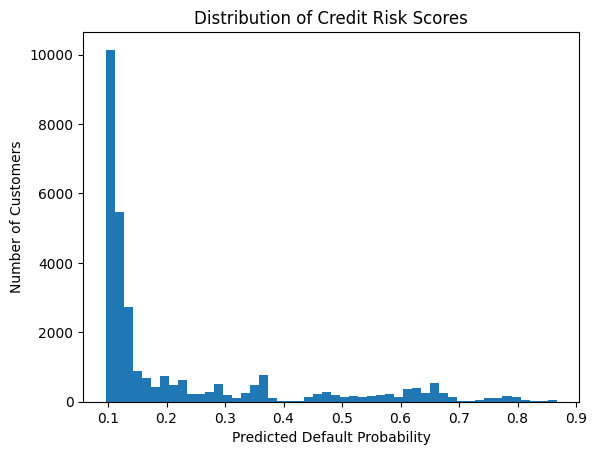

In [ ]:
plt.hist(df['risk_score'], bins=50)
plt.title("Distribution of Credit Risk Scores")
plt.xlabel("Predicted Default Probability")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
def risk_bucket(score):
    if score < 0.3:
        return "Low Risk"
    elif score < 0.6:
        return "Medium Risk"
    else:
        return "High Risk"

df['risk_bucket'] = df['risk_score'].apply(risk_bucket)

df['risk_bucket'].value_counts(normalize=True)

,proportion
risk_bucket,
Low Risk,0.781567
Medium Risk,0.128700
High Risk,0.089733


Thresholds can be further refined based on business risk appetite and regulatory requirements.

In [ ]:
df.groupby('risk_bucket')['default'].mean().sort_values()

,default
risk_bucket,
Low Risk,0.130976
Medium Risk,0.429940
High Risk,0.707652


In [ ]:
pd.crosstab(
    df['risk_bucket'],
    df['default'],
    normalize='index'
)

default,0,1
risk_bucket,,
High Risk,0.292348,0.707652
Low Risk,0.869024,0.130976
Medium Risk,0.570060,0.429940


In [ ]:
silent_stress = df[
    (df['risk_bucket'] == 'High Risk') &
    (df['pay_delay_trend'] > 0)
]

silent_stress.shape

(2341, 33)

In [ ]:
import numpy as np

explain_cols = features + ['risk_score', 'risk_bucket']

df[explain_cols].sort_values(
    by='risk_score',
    ascending=False
).head(10)

,pay_delay_trend,pay_delay_volatility,recency_weighted_stress,bill_payment_ratio,risk_score,risk_bucket
29366,0.142857,0.408248,32.0,300.000000,0.866751,High Risk
21667,0.142857,0.408248,32.0,322.000000,0.866751,High Risk
27160,0.142857,0.408248,32.0,300.000000,0.866751,High Risk
26801,0.142857,0.408248,32.0,2500.000000,0.866404,High Risk
15427,0.142857,0.408248,32.0,2083.333333,0.866404,High Risk
21012,0.142857,0.408248,32.0,2500.000000,0.866404,High Risk
27536,0.142857,0.408248,32.0,2487.000000,0.866404,High Risk
24345,0.142857,0.408248,32.0,2500.000000,0.866404,High Risk
29991,0.142857,0.408248,32.0,2500.000000,0.866404,High Risk
28851,0.142857,0.408248,32.0,2500.000000,0.866404,High Risk


In [ ]:
action_map = {
    "Low Risk": "Increase credit line / rewards",
    "Medium Risk": "Monitor monthly, soft nudges",
    "High Risk": "Early intervention, payment plans"
}

df['recommended_action'] = df['risk_bucket'].map(action_map)

df[['risk_bucket', 'recommended_action']].value_counts()

,,count
risk_bucket,recommended_action,
Low Risk,Increase credit line / rewards,23447
Medium Risk,"Monitor monthly, soft nudges",3861
High Risk,"Early intervention, payment plans",2692


In [ ]:
df.to_csv(
    "/content/drive/My Drive/Credit_Risk_Project/data/final_scored_customers.csv",
    index=False
)

print("Final scored dataset saved.")

Final scored dataset saved.


### Early-Warning Insight:
After removing direct delinquency indicators, the model continues to identify risk using historical instability and worsening repayment patterns.

This suggests financial stress emerges as behavioral inconsistency before formal default, enabling proactive intervention.

### Model Limitations

1.The model is trained on historical data and assumes that past customer behavior will remain stable in the future. Sudden economic shocks or policy changes may reduce predictive accuracy.

2.The dataset represents a specific population and time period, which limits generalization to other geographies or customer segments.

3.Logistic Regression assumes linear relationships between features and default risk, which may oversimplify complex financial behaviors.

4.Feature engineering is based on aggregated monthly data and may not capture short-term behavioral changes.

### Bias and Fairness Considerations

The model does not explicitly use sensitive attributes such as gender or age, but proxy variables (e.g., credit limit, payment history) may indirectly introduce bias.

Customers with limited credit history may be unfairly classified as higher risk due to lack of behavioral data.

Continuous monitoring is required to ensure that model decisions do not disproportionately impact specific demographic groups.

### Ethical Use of Credit Risk Models

The model should be used as a decision-support tool, not as the sole basis for credit approval or rejection.

Human oversight is necessary, especially for borderline cases.

Customers should be provided transparency regarding factors influencing credit decisions wherever possible.

### Model Governance and Monitoring

Model performance should be periodically reviewed using metrics such as ROC-AUC and default rate stability.

Risk thresholds may need recalibration over time as customer behavior and economic conditions evolve.

Versioning and documentation of datasets and model parameters are essential for auditability.